In [1]:
!pip install scikit-learn pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)
from sklearn.dummy import DummyClassifier

np.random.seed(42)
print("Tudo importado com sucesso!")

Tudo importado com sucesso!


In [3]:
import zipfile

with zipfile.ZipFile("archive.zip", "r") as z:
    print(z.namelist())
    z.extractall(".")

df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")
print("Shape:", df.shape)
print(df.head())

['Sleep_health_and_lifestyle_dataset.csv']
Shape: (374, 13)
   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   
4          5   Male   28  Sales Representative             5.9   

   Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                 6                       42             6   Overweight   
1                 6                       60             8       Normal   
2                 6                       60             8       Normal   
3                 4                       30             8        Obese   
4                 4                       30             8        Obese   

  Blood Pressure  Heart Rate  Daily Steps Sleep Disorder  
0         126/83          77     

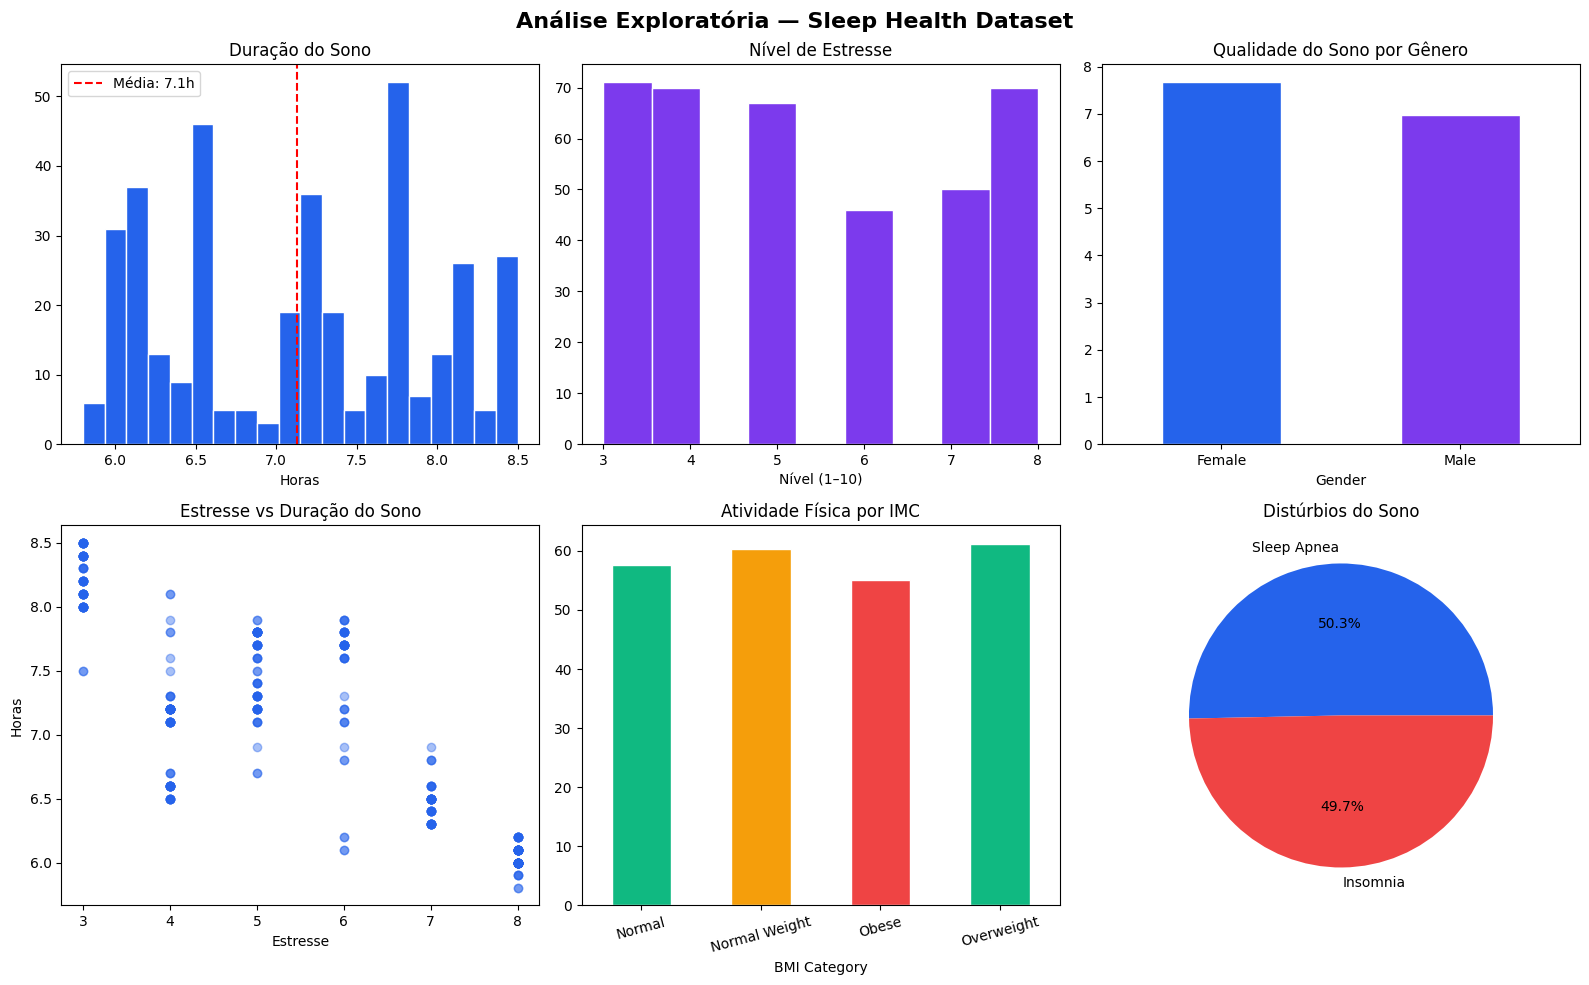

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Análise Exploratória — Sleep Health Dataset", fontsize=16, fontweight="bold")

# Distribuição do sono
axes[0,0].hist(df["Sleep Duration"], bins=20, color="#2563eb", edgecolor="white")
axes[0,0].axvline(df["Sleep Duration"].mean(), color="red", linestyle="--", label=f"Média: {df['Sleep Duration'].mean():.1f}h")
axes[0,0].set_title("Duração do Sono")
axes[0,0].set_xlabel("Horas")
axes[0,0].legend()

# Nível de estresse
axes[0,1].hist(df["Stress Level"], bins=9, color="#7c3aed", edgecolor="white")
axes[0,1].set_title("Nível de Estresse")
axes[0,1].set_xlabel("Nível (1–10)")

# Qualidade por gênero
df.groupby("Gender")["Quality of Sleep"].mean().plot(kind="bar", ax=axes[0,2], color=["#2563eb","#7c3aed"], edgecolor="white")
axes[0,2].set_title("Qualidade do Sono por Gênero")
axes[0,2].tick_params(axis="x", rotation=0)

# Estresse x Duração
axes[1,0].scatter(df["Stress Level"], df["Sleep Duration"], alpha=0.4, color="#2563eb")
axes[1,0].set_title("Estresse vs Duração do Sono")
axes[1,0].set_xlabel("Estresse")
axes[1,0].set_ylabel("Horas")

# Atividade por IMC
df.groupby("BMI Category")["Physical Activity Level"].mean().plot(
    kind="bar", ax=axes[1,1], color=["#10b981","#f59e0b","#ef4444"], edgecolor="white"
)
axes[1,1].set_title("Atividade Física por IMC")
axes[1,1].tick_params(axis="x", rotation=15)

# Distúrbios
df["Sleep Disorder"].value_counts().plot(
    kind="pie", ax=axes[1,2], autopct="%1.1f%%",
    colors=["#2563eb","#ef4444","#f59e0b"]
)
axes[1,2].set_title("Distúrbios do Sono")
axes[1,2].set_ylabel("")

plt.tight_layout()
plt.savefig("eda_sono.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
# Rótulo binário
df["target"] = (df["Quality of Sleep"] >= 7).astype(int)
print("Distribuição:", df["target"].value_counts().to_dict())

# Encoding
le = LabelEncoder()
df["Gender_enc"]   = le.fit_transform(df["Gender"])
df["BMI_enc"]      = le.fit_transform(df["BMI Category"])
df["Disorder_enc"] = le.fit_transform(df["Sleep Disorder"])

features = ["Age","Sleep Duration","Physical Activity Level","Stress Level",
            "Heart Rate","Daily Steps","Gender_enc","BMI_enc","Disorder_enc"]

X = df[features]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Treino: {X_train.shape[0]} | Teste: {X_test.shape[0]}")

Distribuição: {1: 257, 0: 117}
Treino: 299 | Teste: 75


In [6]:
# Baseline
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train_sc, y_train)
baseline_acc = accuracy_score(y_test, dummy.predict(X_test_sc))

# MLP
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
)
mlp.fit(X_train_sc, y_train)
y_pred = mlp.predict(X_test_sc)

acc = accuracy_score(y_test, y_pred)
print(f"Acurácia MLP:      {acc*100:.1f}%")
print(f"Acurácia baseline: {baseline_acc*100:.1f}%")
print(f"Épocas:            {mlp.n_iter_}")
print()
print(classification_report(y_test, y_pred, target_names=["Ruim","Boa"]))

Acurácia MLP:      94.7%
Acurácia baseline: 69.3%
Épocas:            27

              precision    recall  f1-score   support

        Ruim       1.00      0.83      0.90        23
         Boa       0.93      1.00      0.96        52

    accuracy                           0.95        75
   macro avg       0.96      0.91      0.93        75
weighted avg       0.95      0.95      0.95        75



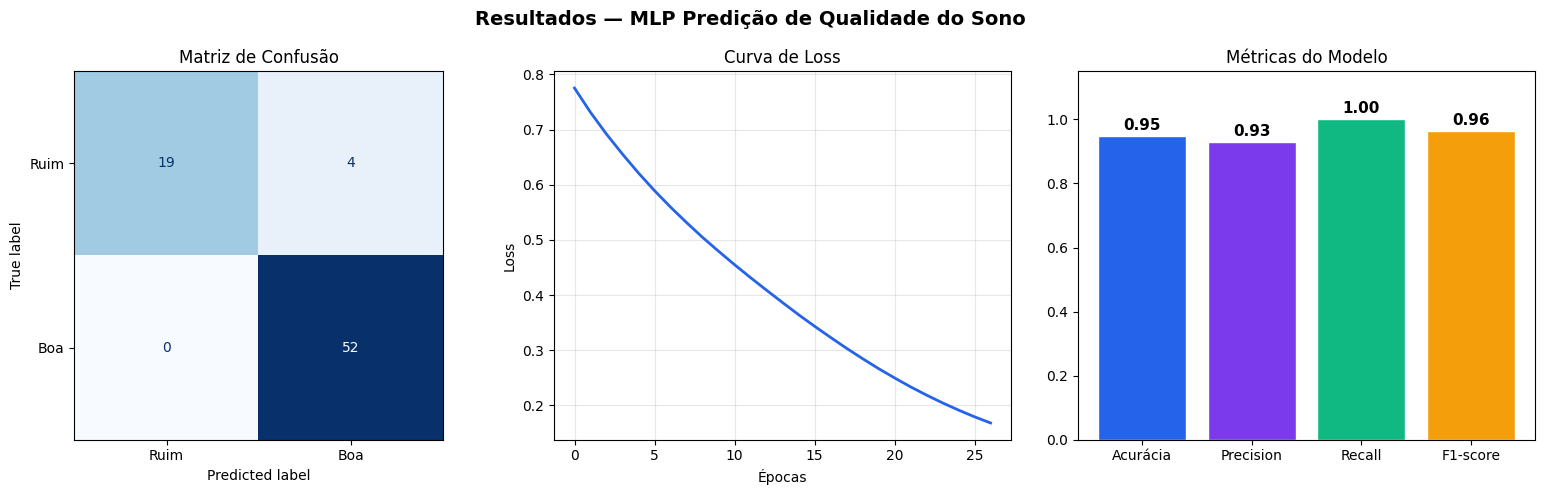

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Resultados — MLP Predição de Qualidade do Sono", fontsize=14, fontweight="bold")

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Ruim","Boa"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusão")

# Curva de loss
axes[1].plot(mlp.loss_curve_, color="#2563eb", linewidth=2)
axes[1].set_title("Curva de Loss")
axes[1].set_xlabel("Épocas")
axes[1].set_ylabel("Loss")
axes[1].grid(alpha=0.3)

# Métricas
metricas = {
    "Acurácia": acc,
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred),
}
bars = axes[2].bar(metricas.keys(), metricas.values(), color=["#2563eb","#7c3aed","#10b981","#f59e0b"], edgecolor="white")
axes[2].set_ylim(0, 1.15)
for bar, val in zip(bars, metricas.values()):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{val:.2f}", ha="center", fontsize=11, fontweight="bold")
axes[2].set_title("Métricas do Modelo")

plt.tight_layout()
plt.savefig("resultados_mlp.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
novo = pd.DataFrame([{
    "Age": 29,
    "Sleep Duration": 5.5,
    "Physical Activity Level": 20,
    "Stress Level": 8,
    "Heart Rate": 82,
    "Daily Steps": 4500,
    "Gender_enc": 1,
    "BMI_enc": 1,
    "Disorder_enc": 2
}])

pred  = mlp.predict(scaler.transform(novo))[0]
proba = mlp.predict_proba(scaler.transform(novo))[0]

print("── Predição para novo usuário ──")
print(f"Qualidade do sono: {'BOA ' if pred == 1 else 'RUIM '}")
print(f"Confiança: {max(proba)*100:.1f}%")

── Predição para novo usuário ──
Qualidade do sono: RUIM 
Confiança: 61.0%
